# Import Libraries and Data

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv("heart.csv")
df.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


# EDA And Data Cleaning

In [3]:
df.columns

Index(['Age', 'Sex', 'ChestPainType', 'RestingBP', 'Cholesterol', 'FastingBS',
       'RestingECG', 'MaxHR', 'ExerciseAngina', 'Oldpeak', 'ST_Slope',
       'HeartDisease'],
      dtype='object')

In [4]:
df.shape

(918, 12)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB


In [6]:
df.describe() # only for numeric data

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
count,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000
mean,53.510893,132.396514,198.799564,0.233115,136.809368,0.887364,0.553377
std,9.432617,18.514154,109.384145,0.423046,25.460334,1.066570,0.497414
min,28.000000,0.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.000000,120.000000,173.250000,0.000000,120.000000,0.000000,0.000000
50%,54.000000,130.000000,223.000000,0.000000,138.000000,0.600000,1.000000
75%,60.000000,140.000000,267.000000,0.000000,156.000000,1.500000,1.000000
max,77.000000,200.000000,603.000000,1.000000,202.000000,6.200000,1.000000


In [7]:
df.duplicated().sum()

np.int64(0)

<Axes: xlabel='HeartDisease'>

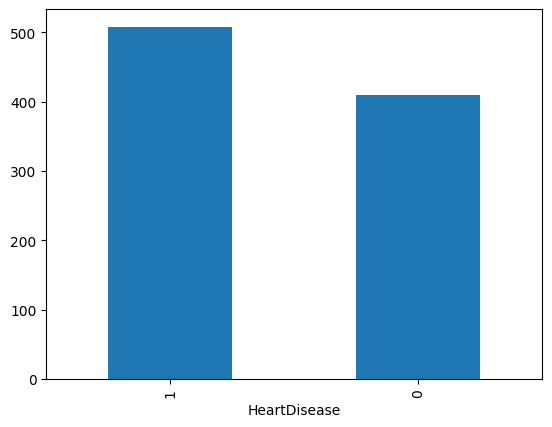

In [8]:
df['HeartDisease'].value_counts().plot(kind = 'bar')

In [9]:
df.isnull().sum()

Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64

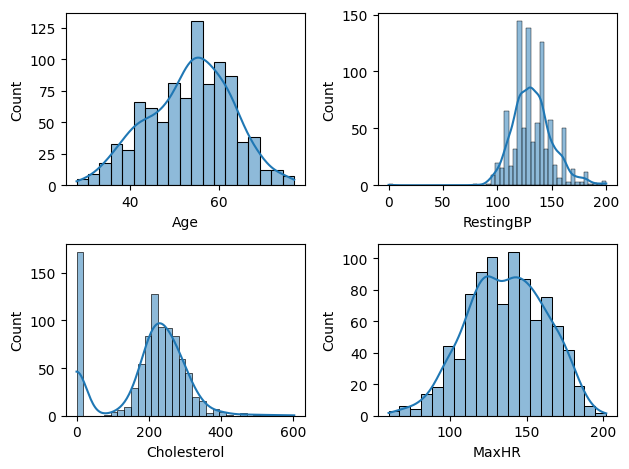

In [10]:
def plotting(var, num):
    plt.subplot(2,2, num)
    sns.histplot(df[var], kde = True)
plotting('Age', 1)
plotting('RestingBP', 2)
plotting('Cholesterol', 3)
plotting('MaxHR', 4)
plt.tight_layout()

In [11]:
df['Cholesterol'].value_counts() # 172 people has 0 cholestrol which is not possible so we will clean data

Cholesterol
0      172
254     11
220     10
223     10
204      9
      ... 
353      1
278      1
157      1
176      1
131      1
Name: count, Length: 222, dtype: int64

In [12]:
# 1 person has 0 RestingBP which is also impossible so we will also clean data
df['RestingBP'].value_counts().to_frame()

,count
RestingBP,
120,132
130,118
140,107
110,58
150,55
...,...
101,1
117,1
192,1


In [13]:
# df.loc[row_selection, column_selection] we clean Cholestrol column
ch_mean = df.loc[df['Cholesterol'] != 0, 'Cholesterol'].mean()
df['Cholesterol'] = df['Cholesterol'].replace(0, ch_mean).round(2)

In [14]:
resting_bp_mean = df.loc[df['RestingBP'] != 0, 'RestingBP'].mean() # we clean RestingBP column
df['RestingBP'] = df['RestingBP'].replace(0, resting_bp_mean).round(2)

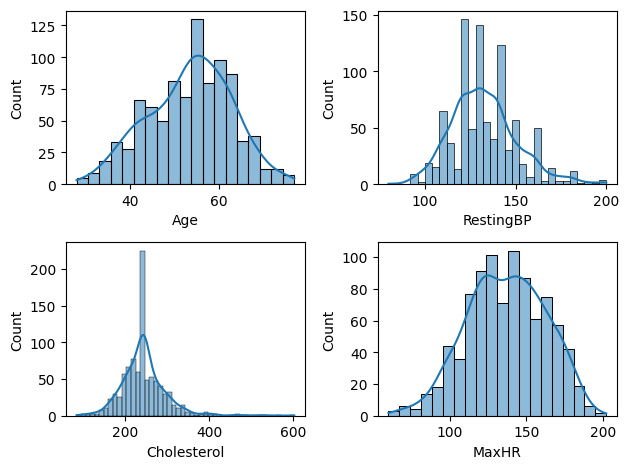

In [15]:
def plotting(var, num):
    plt.subplot(2,2, num)
    sns.histplot(df[var], kde = True)
plotting('Age', 1)
plotting('RestingBP', 2)
plotting('Cholesterol', 3)
plotting('MaxHR', 4)
plt.tight_layout()

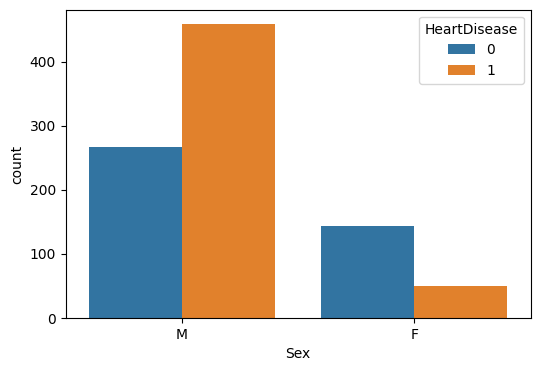

In [16]:
# For categorial variable we use countplot
plt.figure(figsize=(6,4))
sns.countplot(x = df['Sex'], hue = df['HeartDisease'])
plt.show()

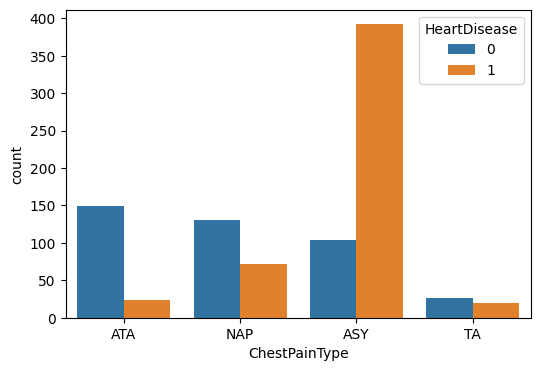

In [17]:
plt.figure(figsize=(6,4))
sns.countplot(x = df['ChestPainType'], hue = df['HeartDisease'])
plt.show()

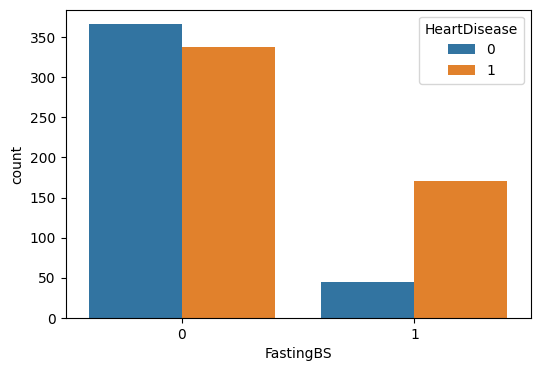

In [18]:
plt.figure(figsize=(6,4))
sns.countplot(x = df['FastingBS'], hue = df['HeartDisease'])
plt.show()

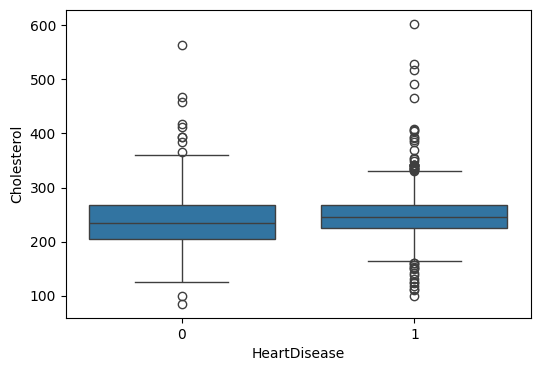

In [19]:
# Boxplot can compare categorial and numeric variables
plt.figure(figsize=(6,4))
sns.boxplot(x = 'HeartDisease', y = 'Cholesterol', data = df)
plt.show()

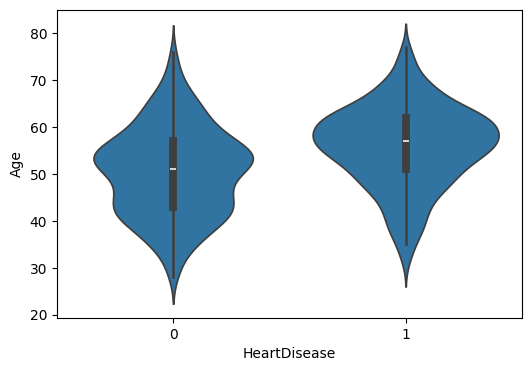

In [20]:
plt.figure(figsize=(6,4))
sns.violinplot(x = 'HeartDisease', y = 'Age', data = df)
plt.show()

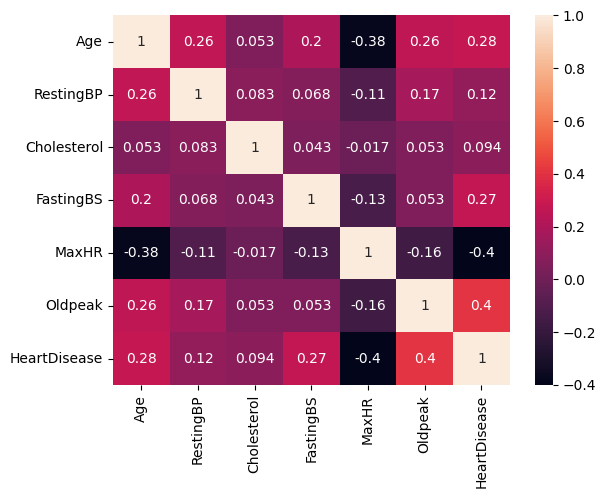

In [21]:
sns.heatmap(df.corr(numeric_only= True), annot = True)
plt.show()

# Data Preprocessing

In [22]:
df_encode = pd.get_dummies(df, drop_first = True)

In [23]:
df_encode = df_encode.astype(int)

In [24]:
df_encode.columns

Index(['Age', 'RestingBP', 'Cholesterol', 'FastingBS', 'MaxHR', 'Oldpeak',
       'HeartDisease', 'Sex_M', 'ChestPainType_ATA', 'ChestPainType_NAP',
       'ChestPainType_TA', 'RestingECG_Normal', 'RestingECG_ST',
       'ExerciseAngina_Y', 'ST_Slope_Flat', 'ST_Slope_Up'],
      dtype='object')

# Models

In [25]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score, classification_report 
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

In [26]:
X = df_encode.drop('HeartDisease', axis = 1)
y = df_encode['HeartDisease']

In [27]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

In [28]:
# Feature Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.fit_transform(X_test)

In [29]:
models = {
    "Logistic Regression" : LogisticRegression(),
    "KNN" : KNeighborsClassifier(),
    "Naive Byeas" : GaussianNB(),
    "Decision Tree" : DecisionTreeClassifier(),
    "SVM" : SVC()
}
result = []

In [30]:
for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    result.append({
        "Model" : name,
        "Accuracy" : round(acc, 4),
        "F1 score" : round(f1, 4)
    })

In [31]:
result

[{'Model': 'Logistic Regression', 'Accuracy': 0.8696, 'F1 score': 0.8857},
 {'Model': 'KNN', 'Accuracy': 0.8641, 'F1 score': 0.8815},
 {'Model': 'Naive Byeas', 'Accuracy': 0.8533, 'F1 score': 0.8683},
 {'Model': 'Decision Tree', 'Accuracy': 0.7717, 'F1 score': 0.7921},
 {'Model': 'SVM', 'Accuracy': 0.8478, 'F1 score': 0.8679}]

The Best Model is Logistic Regression

In [32]:
import joblib
joblib.dump(models['Logistic Regression'], 'Logistic_Regression_HD_prediction.pkl')
joblib.dump(scaler, 'scaler.pkl')
joblib.dump(X.columns.tolist(), 'columns.pkl')

['columns.pkl']